###  all imports 

In [1]:
# imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
from PIL import Image
import io
import cairosvg


project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

import src.pc.data_gen.data_generator as dgen
import src.pc.data_gen.test_data_generator as tgen
from src.pc.plot_gen.multi_cat import MultiCatPCPGenerator
from src.pc.plot_gen.single_cat import SingleCatPCPGenerator
from src.pc.plot_gen.axes_crop import CroppingProcessor
from src.pc.plot_gen.category_separation import CategorySeparator
from src.pc.data_gen.real_dist_info import extract_distributions_from_excel, extract_dist_plots_from_excel

# import custom_dataset_unet as cus
from show_image import show_images_from_folder, plot_crop_lines

# paths

#synthetic csvs
raw_data_path = os.path.join(project_root, "data/raw_synthetic/training/data_example")

test_data_path = os.path.join(project_root, "data/raw_synthetic/real_inspired_data")

#synthetic plots multi categories 
plot_paths = os.path.join(project_root, "data/synthetic_plots/training/multi_plot_example")

#synthetic plots single category 
splot_paths = os.path.join(project_root, "data/synthetic_plots/training/single_plot_example")

vis_dir = os.path.join(project_root, "visualizations")

### test_set distriubtion generation using real world distriubtion information 


In [5]:
excel_path = "real_world_dis_info.xlsx"
axes_dist, cat_dist, rows_dist = extract_distributions_from_excel(excel_path)

dgen.generate_synthetic_datasets_from_distributions(
    directory_path="out_comb/csvs",
    k=15,  # or 5000
    axes_distribution=axes_dist,
    categories_distribution=cat_dist,
    rows_distribution=rows_dist,
    seed=767  # for reproducibility
)

[✓] Generated 15 datasets using real-world distributions.
[✓] Annotations saved to: out_comb/csvs/annotations.json


### Generate plots and annotations jsons from csvs 

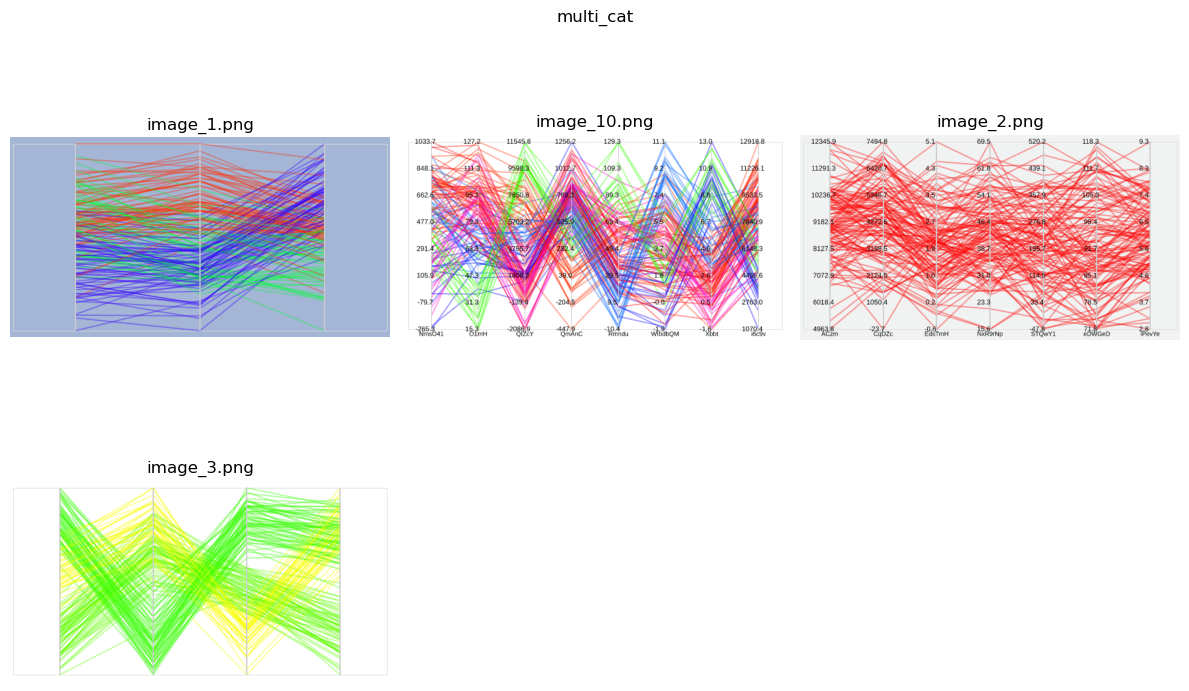

In [3]:
bg_dist, grid_dist,ticks_dist = extract_dist_plots_from_excel("real_world_dis_info_rgb.xlsx")
# print(bg_dist, grid_dist,ticks_dist)  56666
plotter = MultiCatPCPGenerator(seed=56666) # 45345 # 56666
plotter.generate_batch(
    input_dir="out_comb/csvs",
    output_dir="out_comb/plots_1",
    svg_dir="out_comb/svgs_1",
    num_files=10,
    background_distribution=bg_dist,
    grid_distribution=grid_dist,
    ticks_labels_distribution=ticks_dist, 
    no_ticks_output_dir="out_comb/plots_no_ticks_1",
    per_cat_dir ="out_comb/plots_per_cat_1",
    per_cat_ntl_dir ="out_comb/plots_per_cat_ntl_1"
        
)

show_images_from_folder("out_comb/plots_1", title="multi_cat")

### cropping 

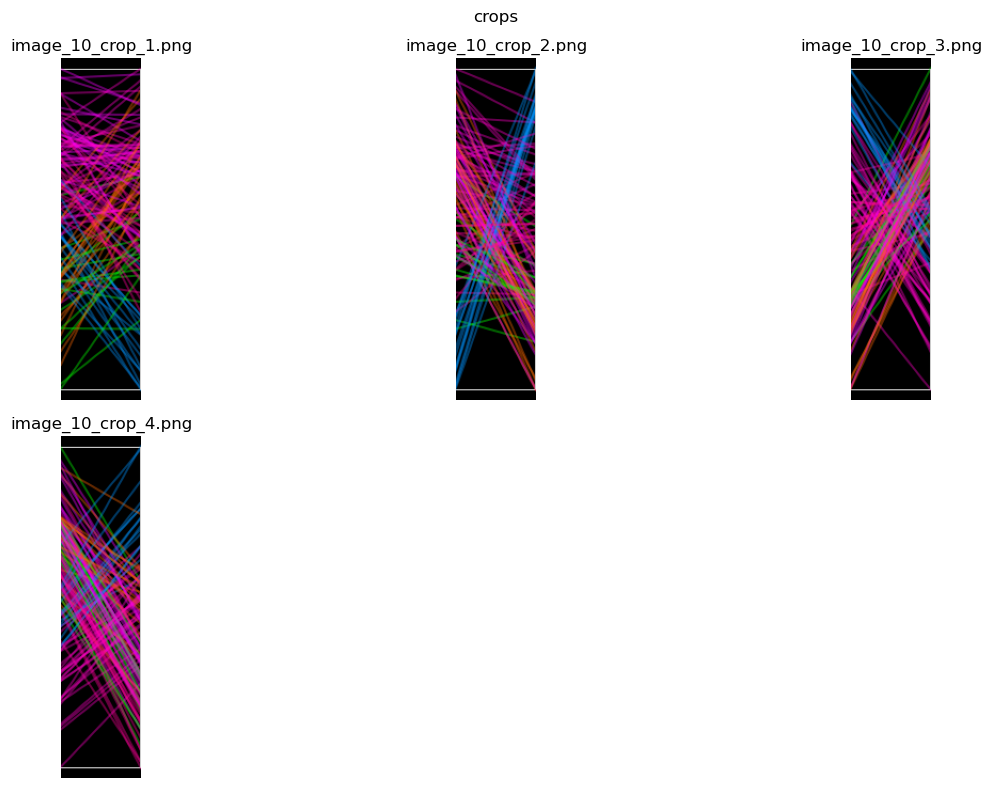

In [10]:
cp = CroppingProcessor()
cp.create_crops("out_comb/plots_no_ticks_1", "out_comb/cropping_plots_no_ticks_1")
cp.create_crops("out_comb/plots_1", "out_comb/cropping_plots_1")
cp.create_crops("out_comb/plots_per_cat_1", "out_comb/cropping_plots_pc_1")
cp.create_crops("out_comb/plots_per_cat_ntl_1", "out_comb/cropping_plots_pn_1")
show_images_from_folder("out_comb/cropping_plots_no_ticks_1", title="crops")

In [12]:
plot_crop_lines(
    json_file='out_comb/plots_1/image_5.json',
    filename="image_5_crop_2.png",
    image_path='out_comb/cropping_plots_no_ticks_1/image_5_crop_2.png',
    show_points= True,
    show_lines = True
)

# plot_crop_category_lines(
#     json_file='out_comb/plot_1/image_3.json',
#     filename="image_3_6ayE_crop_2.png",
#     image_path='out_comb/cropping_plots_pn_1/image_3_6ayE_crop_2.png'
# )





NameError: name 'plot_crop_category_lines' is not defined

### Color histogram detection

In [ ]:
# Load the new image
import numpy as np
import cv2
from scipy.signal import find_peaks

# # Convert image to HSV
# img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

# # Extract H (Hue) channel only
# hue_channel = img_hsv[:,:,0].flatten()
# sat_channel = img_hsv[:,:,1].flatten()
# val_channel = img_hsv[:,:,2].flatten()

# # Mask out very low saturation pixels (grays/whites)
# mask = sat_channel > 50
# hue_filtered = hue_channel[mask]

# # Build histogram of Hue values (0-179 in OpenCV HSV)
# hist, bins = np.histogram(hue_filtered, bins=180, range=(0,180))

# # Find peaks in histogram
# peaks, _ = find_peaks(hist, height=np.max(hist)*0.1, distance=10)  # threshold = 10% of max

# # Convert peak hues back to RGB
# dominant_colors_hsv = [(int(h), 200, 200) for h in peaks]  # use fixed S,V for vivid color display
# dominant_colors_rgb = [cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0,0] 
#                        for hsv in dominant_colors_hsv]

# # Plot histogram and peaks
# plt.figure(figsize=(10,4))
# plt.plot(hist, label="Hue Histogram")
# plt.plot(peaks, hist[peaks], "rx", label="Detected Peaks")
# plt.title("Hue Histogram with Peaks")
# plt.xlabel("Hue Value (0-179)")
# plt.ylabel("Frequency")
# plt.legend()
# plt.show()

# dominant_colors_rgb

img2 = Image.open(image_over).convert("RGB")
img2_np = np.array(img2)

# Convert to HSV
img2_hsv = cv2.cvtColor(img2_np, cv2.COLOR_RGB2HSV)

# Extract channels
hue2 = img2_hsv[:,:,0].flatten()
sat2 = img2_hsv[:,:,1].flatten()

# Mask low saturation pixels (remove background/white)
mask2 = sat2 > 50
hue2_filtered = hue2[mask2]

# Histogram of hue
hist2, bins2 = np.histogram(hue2_filtered, bins=180, range=(0,180))

# Find peaks
peaks2, _ = find_peaks(hist2, height=np.max(hist2)*0.1, distance=10)

# Convert peaks to RGB colors
dominant_colors_hsv2 = [(int(h), 200, 200) for h in peaks2]
dominant_colors_rgb2 = [cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0,0] 
                        for hsv in dominant_colors_hsv2]

# Plot histogram with peaks
plt.figure(figsize=(10,4))
plt.plot(hist2, label="Hue Histogram")
plt.plot(peaks2, hist2[peaks2], "rx", label="Detected Peaks")
plt.title("Hue Histogram with Peaks (New Image)")
plt.xlabel("Hue Value (0-179)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(dominant_colors_rgb2)

import cv2
import numpy as np
from PIL import Image
from scipy.signal import find_peaks

def extract_dominant_colors(image_path, sat_thresh=50, peak_prominence=0.1, distance=10):
    """
    Extract dominant colors (HSV, RGB, HEX) from an image using histogram peaks.

    Args:
        image_path (str): Path to the image file
        sat_thresh (int): Minimum saturation to keep (default=50, removes gray/white)
        peak_prominence (float): Fraction of max histogram height to consider as peak
        distance (int): Minimum distance between peaks in hue values

    Returns:
        dominant_colors (list of dict): List of dominant colors with HSV, RGB, HEX
    """
    # Load and convert to HSV
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

    # Extract channels
    hue = img_hsv[:,:,0].flatten()
    sat = img_hsv[:,:,1].flatten()

    # Mask low saturation (ignore background/white/gray)
    mask = sat > sat_thresh
    hue_filtered = hue[mask]

    # Histogram of Hue
    hist, bins = np.histogram(hue_filtered, bins=180, range=(0,180))

    # Find peaks
    peaks, _ = find_peaks(hist, height=np.max(hist)*peak_prominence, distance=distance)

    dominant_colors = []
    for h in peaks:
        hsv = (int(h), 200, 200)  # vivid S,V for visualization
        rgb = cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0,0].tolist()
        hex_code = '#%02x%02x%02x' % tuple(rgb)

        dominant_colors.append({
            "HSV": hsv,
            "RGB": tuple(rgb),
            "HEX": hex_code
        })

    return dominant_colors


colors = extract_dominant_colors(image_over)
for c in colors:
    print(c)





### Category separation from crops 

In [8]:
sep = CategorySeparator()
# sep.process_single_image_enhanced(
#     "out_comb/cropping_plots_no_ticks/image_4_crop_2.png",
#     "out_comb/plots/image_4.json",
#     "out_comb/cat_sep"
# )


sep.process_batch(
    "out_comb/cropping_plots",
    "out_comb/plots",
    "out_comb/cat_sep",
    method="hist_enhanced"
)


Saved batch results in out_comb/cat_sep


### unet denoising 

In [ ]:
# Example usage
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1]
])


In [ ]:
dataset = cus.CustomHSVMatchingDatasetSDMask(
    input_json = "dataset/training_data/data04_color_thres/line_with_sepimg.json", #cls_line_json_path 
    ground_truth_json= "dataset/training_data/data04_gt_plots_crops/gt_line_color.json",
    input_dir="dataset/training_data/data04_cluster_thres",
    ground_truth_dir="dataset/training_data/data04_gt_plots_crops",
    mask_dir="dataset/training_data/data04_gt_plots_crops_masks",
    transform=transform,
    hsv_tolerance=0.1  # Adjust as needed
)

In [ ]:
# unet inference 


tester = UNetTester(config, test_config)

# Run just one test (color)
tester.run(
    input_dir=test_config.m_color_sep_plots,
    output_dir=test_config.m_color_denoised_plots,
    description="Multi-color separation"
)